# Demo: SummaryPlot

This notebook demonstrates the `SummaryPlot` class for measured-data summary plots.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pythermalcomfort.models import pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import SummaryPlot, ThresholdPlot

## Create a Small Measured DataFrame

In [2]:
df = pd.DataFrame(
    {
        "tdb": [20.0, 22.0, 23.5, 24.5, 26.0, 27.5, 29.0, 20.0],
        "rh": [50.0, 45.0, 50.0, 50.0, 55.0, 60.0, 60.0, 65.0],
        "tr": [20.0, 21.5, 23.5, 24.5, 26.0, 28.0, 29.5, 20.0],
        "vr": [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10],
        "met": [1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        "clo": [0.90, 0.80, 0.60, 0.50, 0.50, 0.40, 0.35, 0.80],
        "wme": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    }
)

df.head(2)

,tdb,rh,tr,vr,met,clo,wme
0,20.0,50.0,20.0,0.1,1.2,0.9,0.0
1,22.0,45.0,21.5,0.1,1.2,0.8,0.0


## Compute PMV and Append to the DataFrame

In [3]:
pmv_value = pmv_ppd_iso(
    tdb=df["tdb"],
    tr=df["tr"],
    vr=df["vr"],
    rh=df["rh"],
    met=df["met"],
    clo=df["clo"],
    wme=df["wme"],
).pmv

df["pmv"] = pmv_value

df.head(2)

,tdb,rh,tr,vr,met,clo,wme,pmv
0,20.0,50.0,20.0,0.1,1.2,0.9,0.0,-0.50
1,22.0,45.0,21.5,0.1,1.2,0.8,0.0,-0.28


## Default Summary Example

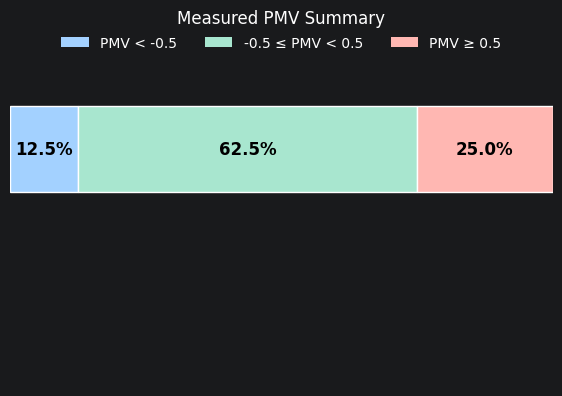

In [4]:
result = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="Measured PMV Summary")
)

## Vertical Summary Example

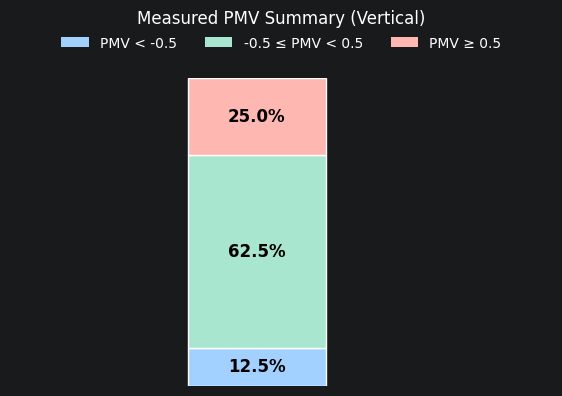

In [5]:
result_vertical = (
    SummaryPlot(df)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(vertical=True, title="Measured PMV Summary (Vertical)")
)

plt.show()

## Custom Labels and Colors

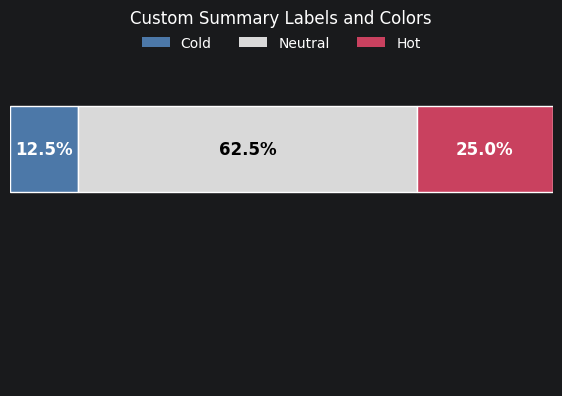

In [6]:
result_custom = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Neutral", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="Custom Summary Labels and Colors")
)

plt.show()

## UTCI Summary Example

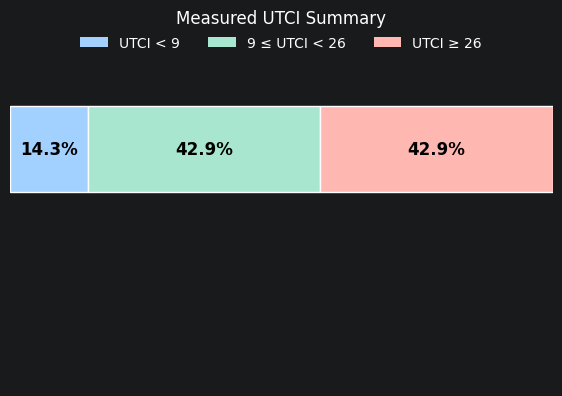

In [7]:
df_utci = pd.DataFrame(
    {
        "tdb": [10.0, 14.0, 18.0, 24.0, 28.0, 32.0, 36.0],
        "tr": [5.0, 10.0, 18.0, 24.0, 28.0, 32.0, 36.0],
        "v": [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        "rh": [30.0, 40.0, 45.0, 50.0, 55.0, 60.0, 70.0],
    }
)

df_utci["utci"] = [
    utci(tdb=row.tdb, tr=row.tr, v=row.v, rh=row.rh).utci
    for row in df_utci.itertuples(index=False)
]

result_utci = (
    SummaryPlot(df_utci)
    .set_regions(output="utci", thresholds=[9, 26])
    .plot(title="Measured UTCI Summary")
)

plt.show()

In [8]:
result_utci.percentages

UTCI < 9         14.3
9 ≤ UTCI < 26    42.9
UTCI ≥ 26        42.9
Name: proportion, dtype: float64

## Threshold Plot + Summary Panel

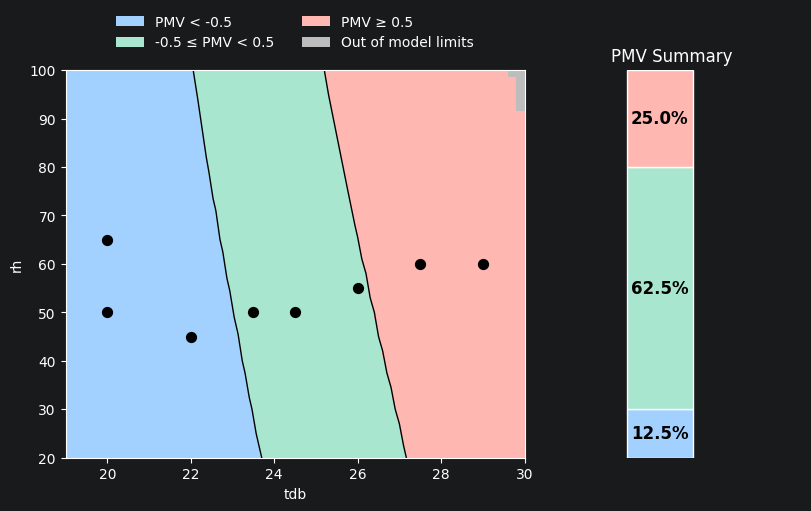

In [9]:
fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(8, 5),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [3.0, 1.7]},
)

threshold_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 19.0, 30.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, legend_kws={"ncol": 2})
)

threshold_result.ax.scatter(df["tdb"], df["rh"], color="black", s=50)

sp = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=[],  # Hide labels since we'll show them in the ThresholdPlot legend
    )
    .plot(ax=ax1, title="PMV Summary", vertical=True, legend=False)
)

plt.show()

## Accessing `result.fig`

`result.fig` is the underlying `matplotlib.Figure`. Use it for figure-level operations such as adding a super-title or saving to disk.

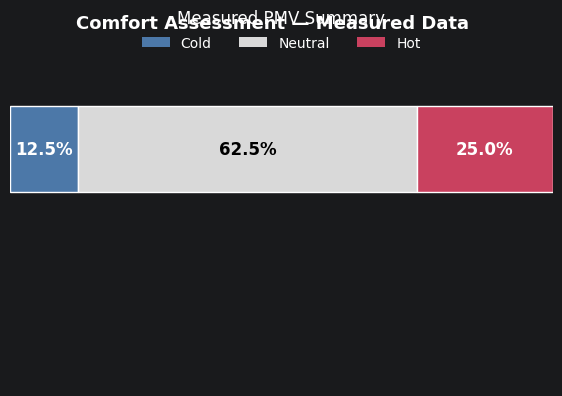

In [10]:
fig_summary = (
    SummaryPlot(df)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Neutral", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="Measured PMV Summary")
)

# result.fig is the underlying Figure — use it for figure-level operations
fig_summary.fig.suptitle(
    "Comfort Assessment — Measured Data",
    y=1.04,
    fontsize=13,
    fontweight="bold",
)

# To save the figure to disk:
# fig_summary.fig.savefig("pmv_summary.png", dpi=150, bbox_inches="tight")

plt.show()